# Modified UCF algorithm using Personalized PageRank as similarity


In this exercise, we will modify the classic User-Based Collaborative Filterring algorithm, by introducing a new notion of similarity between the users.

For this, we will create a graph that symbolizes the similarity of the user. More formally, we will create a graph $G=(V,E)$, where $V(G)$ is the number of users and $E(G)$ the edges of the graph, where:

$$ E =  \{ \{ u,v \} \} : u \in V,  v \in N_k(u) \} $$


The similarity between two users $u$ and $v$ is defined as the Personalized PageRank (PPR) score, which is a steady-state probability that a random walker starting at node $u$ will be at node $v$.


The Modified UCF algorithm score for a user-item pair $(u,i)$ is:

$$\hat r_{u,i} = \frac{\sum_{v \in topk(u)} PPR(u,v) ⋅ r_{v,i}} {\sum_{v \in topk(v)} PPR(u,v)}$$

## Loading the data

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

PATH = '/content/drive/MyDrive/mining/data'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
df_train = pd.read_csv(PATH+'/data_train.csv')
df_test = pd.read_csv(PATH+'/data_test.csv')

df_train.head()

,uid,mid,rating
0,462,214,4.0
1,638,2275,3.0
2,310,2452,3.5
3,319,1654,4.0
4,119,270,3.5


Create a sparse matrix for efficiency purposes, since we might not actually need it as much as we needed it for the UCF implementation.

In [120]:
from scipy.sparse import csr_matrix

R = csr_matrix((df_train['rating'], (df_train['uid'], df_train['mid'])))
R

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 90004 stored elements and shape (671, 9066)>

## UCF using Personalized PageRank

First things first, we copy paste the functions we created for the implementation of UCF. We will make use of them also in this implementation.

In [90]:
def user_mean_rating(R: csr_matrix, u: int):
    return R[R[u, :].nonzero()].mean()

def users_rated_movie(R: csr_matrix, m: int):
    return R[:,m].nonzero()[0]

def compute_score(k_ratings: np.array, k_similarities: np.array):
    denominator = np.sum(k_similarities)
    if denominator == 0:
        return 0

    return k_ratings.dot(k_similarities) / denominator

Now we need to create the graph we talked about. We will create the function `build_graph` to do this. It will also take as an argument an integer `m`, which corresponds to the number of edges each node will try to create. We need to pass as an argument a user-user matrix adjacency matrix $\mathbf{A}$, where:

$$ \mathbf{A}[i,j]=\mathbf{A}[j,i]$$

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

adjacency_similarity_matrix = cosine_similarity(R)
adjacency_similarity_matrix

array([[1.        , 0.        , 0.        , ..., 0.07290656, 0.        ,
        0.01943687],
       [0.        , 1.        , 0.08196459, ..., 0.02846385, 0.16521604,
        0.1011794 ],
       [0.        , 0.08196459, 1.        , ..., 0.09645414, 0.10854304,
        0.15255433],
       ...,
       [0.07290656, 0.02846385, 0.09645414, ..., 1.        , 0.04754552,
        0.0445493 ],
       [0.        , 0.16521604, 0.10854304, ..., 0.04754552, 1.        ,
        0.18647251],
       [0.01943687, 0.1011794 , 0.15255433, ..., 0.0445493 , 0.18647251,
        1.        ]])

In [7]:
import networkx as nx

def build_graph(adj_matrix: np.ndarray, m: int):
    graph = nx.Graph()
    graph.add_nodes_from(range(adj_matrix.shape[0]))

    for u in graph.nodes():
        user_sim_vector = adj_matrix[u]

        user_sim_vector[u] = 0

        most_similar_users = np.argsort(user_sim_vector)[-m:]

        for v in most_similar_users:
            similarity = user_sim_vector[v]
            if similarity > 0:
                if not graph.has_edge(u,v):
                    graph.add_edge(u,v,weight=similarity)


    return graph

In [8]:
print(f'Graph with 10 most-similar: {build_graph(adjacency_similarity_matrix, 10)}')

Graph with 10 most-similar: Graph with 671 nodes and 5692 edges


We will now construct our 3 graphs from our training data.

In [9]:
M = [3,5,10]

graphs = {m: build_graph(adjacency_similarity_matrix, m) for m in M}
graphs

{3: <networkx.classes.graph.Graph at 0x7f934c40dd90>,
 5: <networkx.classes.graph.Graph at 0x7f934c381520>,
 10: <networkx.classes.graph.Graph at 0x7f934cd1fb30>}

The function ``run_ppr`` takes as an argument a graph $G$ and a restart probability $1-alpha$ and runs a Personalized PageRank for every node in our graph.

In [11]:
def run_ppr(graph: nx.Graph, alpha=0.85):
  graph_ppr = {}
  for user in graph.nodes():
    graph_ppr[user] = nx.pagerank(graph, alpha, {user: 1})

  return graph_ppr

We proceed to create what we call a *knowledge base*, which is simply a placeholder for the Personalized PageRank scores of all users for all the graphs we created.

In [12]:
knowledge_base = {}

for graph_n, graph in graphs.items():
  out = run_ppr(graph)
  knowledge_base[graph_n] = out

In [13]:
print(knowledge_base.keys())
print(knowledge_base[3].keys())
print(knowledge_base[3][1].keys())

dict_keys([3, 5, 10])
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 21

Now, we are set and ready to implement the Modified UCF. We define a function `similar_users`, which takes as input a user index `u`, a list of user indices `m_users`, the number of similar users we will try to find `k` and what we call as `graph_key`, which is simply the key value in the dictionary and matches the number $m$ that led to its creation.

In [91]:
def find_similar_users(u: int, m_users: np.array, k: int, graph_key: int):
    similarities= np.array([knowledge_base[graph_key][u][user] for user in m_users])

    topk = np.argsort(similarities)[-k:]
    return m_users[topk], similarities[topk]

We now create the modified ucf algorithm, by following the exact same steps we followed in the classic UCF.

In [98]:
def ucf_graph_predict(u: int, m: int, k: int, graph_key: int):
    users_movie = users_rated_movie(R, m)

    if len(users_movie) == 0:
        return user_mean_rating(R, u)

    best_k_users, sims = find_similar_users(u=u, m_users = users_movie, k=k, graph_key=graph_key)
    return compute_score(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims)

In [93]:
print(f"Predicted rating of user 0 for movie 0, looking at the 10 most similar users: {ucf_graph_predict(0,0,30, 3)}")
print(f"Actual rating: {R[0,0]}")

Predicted rating of user 0 for movie 0, looking at the 10 most similar users: 3.221523070498722
Actual rating: 2.5


To evaluate and find the values of $k,m$ in which the algorithm performs the best on unseen data, we create `predict_ratings` and `tune_and_evaluate`. The second tries all the possible combinations and returns a JSON-like dictionary for us to plot the values of the RMSE.

In [109]:
  from sklearn.metrics import root_mean_squared_error

  test = df_test.to_numpy()

  def predict_ratings(data=test, graph_key=3, k=30):
    users = data[:,0].astype(int)
    movies = data[:,1].astype(int)
    ratings = data[:,2]

    preds = np.array([ucf_graph_predict(users[i], movies[i], k=k, graph_key=graph_key) for i in range(len(test))])

    return root_mean_squared_error(y_pred=preds, y_true=ratings)



  def tune_and_evaluate():
    K = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]

    results = {m: {} for m in knowledge_base.keys()}

    for m in knowledge_base.keys():
      print(f'Evaluating graph_key: {m}')
      for k in K:
        rmse = predict_ratings(graph_key=m, k=k)
        results[m][k] = rmse

    return results

In [110]:
results = tune_and_evaluate()

Evaluating graph_key: 3
Evaluating graph_key: 5
Evaluating graph_key: 10


Lastly, we plot the results of the algorithm on the test data, in order to evaluate its performance and compare it against other recommendation algorithms.

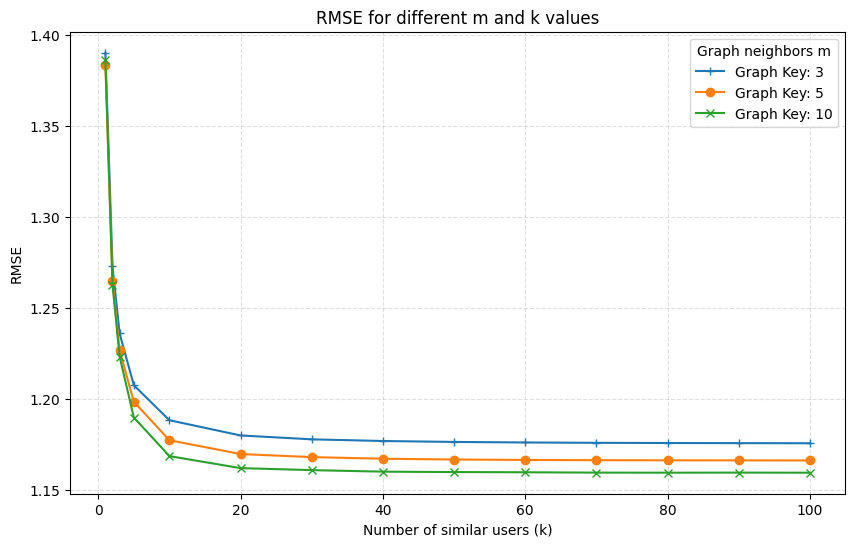

In [119]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

markers = {3: "+", 5: "o", 10: "x"}

for graph_key, k_values in results.items():

    x_axis = k_values.keys()
    y_values = [k_values[k] for k in x_axis]

    ax.plot(
        x_axis,
        y_values,
        marker = markers.get(graph_key, "s"),
        label = f'Graph Key: {graph_key}'
    )

ax.set_title('RMSE for different m and k values')
ax.set_xlabel('Number of similar users (k)')
ax.set_ylabel('RMSE')

ax.legend(title='Graph neighbors m')
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

We cleary see, that the performance is similar to the classic UCF algorithm that we explored the last time. Also, the performance for $m \in \{ 3,5,10\}$ is similar, with more edges in the graph correlating with lower RMSE's.

An important observation, is the fact that after $k=30$, we see a stagnation in performance, in contrast with the other recommendation algorithms we saw, which for every $k>k_{optimal}$ produces worse results.